In [7]:
import numpy as np

# Parameters
m = 2
oneoverm = 1. / m
heat_capacity_ratio = 1e3

# Grid setup
N = 50
beta_d_grid = np.logspace(-6, 3, N)
beta_r_grid = np.logspace(-6, 3, N)

shift_Td = np.zeros((N, N))
amp_Td = np.zeros((N, N))
shift_Tg = np.zeros((N, N))
amp_Tg = np.zeros((N, N))

for i, beta_d in enumerate(beta_d_grid):
    for j, beta_r in enumerate(beta_r_grid):
        beta_g = heat_capacity_ratio * beta_d
        beta_sum = 1. / (1. / beta_g + 1. / beta_d + 1. / beta_r)
        
        D2 = (1 - beta_g * beta_r / oneoverm**2)**2 + (beta_g / oneoverm * beta_r / beta_sum)**2
        Td_real = 1 - beta_g * beta_r / oneoverm**2 + (beta_g / oneoverm)**2 * (beta_r / beta_sum)
        Td_imag = beta_g / oneoverm - (beta_g / oneoverm)**2 * beta_r / oneoverm - beta_g / oneoverm * beta_r / beta_sum

        Tg_real = 1. - beta_g * beta_r / oneoverm**2
        Tg_imag = -beta_g / oneoverm * (beta_r / beta_sum)

        Td_cplx = Td_real + 1j * Td_imag
        Tg_cplx = Tg_real + 1j * Tg_imag

        shift_Td[i, j] = np.angle(Td_cplx) / m
        amp_Td[i, j] = np.abs(Td_cplx) / D2

        shift_Tg[i, j] = np.angle(Tg_cplx) / m
        amp_Tg[i, j] = np.abs(Tg_cplx) / D2


shift_Td[amp_Td < 1e-1] = np.nan
shift_Tg[amp_Tg < 1e-1] = np.nan

#shift_Td[-shift_Td < np.deg2rad(4.5)] = np.nan
#shift_Tg[-shift_Tg < np.deg2rad(4.5)] = np.nan

$T_d$ phase = 9 $^\circ$ contour:
  beta_rad,g range: 1.620e-01 to 4.040e+02
  beta_g range: 1.000e-03 to 1.000e+06
  sample point: beta_g,col=1.000e-03, beta_rad,g=1.620e-01
  sample point: beta_g,col=1.367e+00, beta_rad,g=1.099e+01
  sample point: beta_g,col=1.000e+06, beta_rad,g=1.599e+02
$T_d$ phase = 25 $^\circ$ contour:
  beta_rad,g range: 5.982e-01 to 2.716e+03
  beta_g range: 1.000e-03 to 1.000e+06
  sample point: beta_g,col=1.000e-03, beta_rad,g=5.982e-01
  sample point: beta_g,col=7.667e+02, beta_rad,g=2.683e+03
  sample point: beta_g,col=1.000e+06, beta_rad,g=5.987e+02


<>:32: SyntaxWarning: invalid escape sequence '\c'
<>:32: SyntaxWarning: invalid escape sequence '\c'
/var/folders/8z/9_d9nvkn3r5fdr1hnvvb6rrw0000gn/T/ipykernel_80858/3654762359.py:32: SyntaxWarning: invalid escape sequence '\c'
  axes[0, 1].clabel(td_contours, fmt={9: '9$^\circ$', 25: r'25$^\circ$'}, inline=True, fontsize=11)


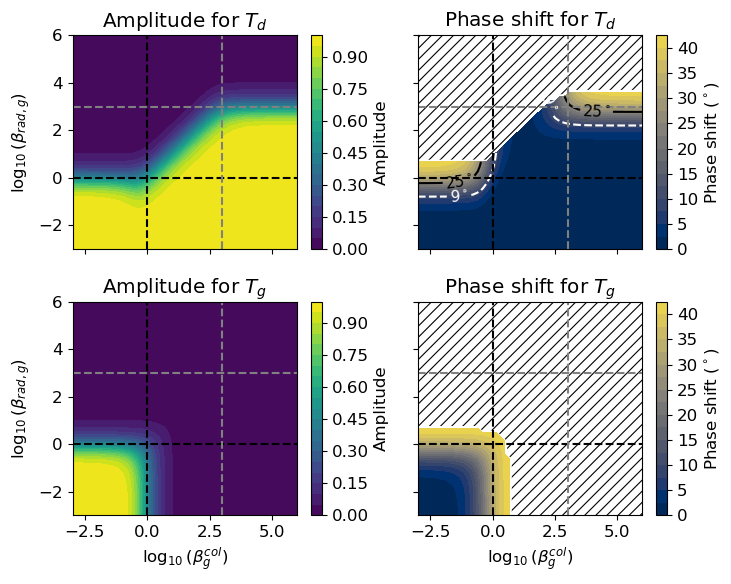

In [12]:
import matplotlib.pyplot as plt
import numpy as np

plt.rc("font", size=12)
plt.rcParams['hatch.color'] = 'k'
plt.rcParams['hatch.linewidth'] = 0.8

fig, axes = plt.subplots(2, 2, figsize=(7.5, 6), sharex=True, sharey=True)

phase_Td_deg = -np.rad2deg(shift_Td.T)
phase_Tg_deg = -np.rad2deg(shift_Tg.T)
x_vals = np.log10(beta_d_grid * heat_capacity_ratio)
y_vals = np.log10(beta_r_grid * heat_capacity_ratio)

# Panel 1: Amplitude for Td
im0 = axes[0, 0].contourf(
    x_vals, y_vals, amp_Td.T, levels=21, cmap='viridis',
    vmax=1, vmin=0
)
axes[0, 0].set_title('Amplitude for $T_d$')
fig.colorbar(im0, ax=axes[0, 0], label='Amplitude')

# Panel 2: Phase shift for Td
im1 = axes[0, 1].contourf(
    x_vals, y_vals, phase_Td_deg,
    levels=int(90 / m / 3) + 1, vmax=90 / m, vmin=0, cmap='cividis'
 )
td_contours = axes[0, 1].contour(
    x_vals, y_vals, phase_Td_deg,
    levels=[9, 25], colors=['white', 'black'], linestyles=['--', '-'], linewidths=1.5
)
axes[0, 1].clabel(td_contours, fmt={9: '9$^\circ$', 25: r'25$^\circ$'}, inline=True, fontsize=11)
axes[0, 1].set_title('Phase shift for $T_d$')
fig.colorbar(im1, ax=axes[0, 1], label=r'Phase shift ($^\circ$)')

# Panel 3: Amplitude for Tg
im2 = axes[1, 0].contourf(
    x_vals, y_vals, amp_Tg.T, levels=21, cmap='viridis',
    vmax=1, vmin=0
)
axes[1, 0].set_title('Amplitude for $T_g$')
fig.colorbar(im2, ax=axes[1, 0], label='Amplitude')

# Panel 4: Phase shift for Tg
im3 = axes[1, 1].contourf(
    x_vals, y_vals, phase_Tg_deg,
    levels=int(90 / m / 3) + 1, vmax=90 / m, vmin=0, cmap='cividis'
 )
axes[1, 1].set_title('Phase shift for $T_g$')
fig.colorbar(im3, ax=axes[1, 1], label=r'Phase shift ($^\circ$)')

for ax in axes[1, :]:
    ax.set_xlabel(r'$\log_{10}(\beta_g^{col})$')
for ax in axes[:, 0]:
    ax.set_ylabel(r'$\log_{10}(\beta_{rad,g})$')

for ax in axes.flatten():
    ax.axvline(0, color='k', linestyle='--')
    ax.axhline(0, color='k', linestyle='--')
    ax.axvline(np.log10(heat_capacity_ratio), color='gray', linestyle='--')
    ax.axhline(np.log10(heat_capacity_ratio), color='gray', linestyle='--')

def add_hatch_overlay(ax, data_mask):
    ax.contourf(
        x_vals, y_vals, data_mask,
        levels=[0.5, 1.5],
        colors='none',
        hatches=['///']
    )

add_hatch_overlay(axes[1, 1], (amp_Tg.T < 1e-1).astype(int))
add_hatch_overlay(axes[0, 1], (amp_Td.T < 1e-1).astype(int))

for level, segments in zip(td_contours.levels, td_contours.allsegs):
    valid_segments = [segment for segment in segments if len(segment) > 0]
    if not valid_segments:
        print(f'No contour found for {level:.0f} deg.')
        continue

    vertices = np.vstack(valid_segments)
    beta_g_col_vals = 10 ** vertices[:, 0]
    beta_rad_g_vals = 10 ** vertices[:, 1]

    print(rf'$T_d$ phase = {level:.0f} $^\circ$ contour:')
    print(f'  beta_rad,g range: {beta_rad_g_vals.min():.3e} to {beta_rad_g_vals.max():.3e}')
    print(f'  beta_g range: {beta_g_col_vals.min():.3e} to {beta_g_col_vals.max():.3e}')

    sample_indices = np.linspace(0, len(vertices) - 1, min(3, len(vertices)), dtype=int)
    for index in sample_indices:
        print(
            '  sample point: '
            f'beta_g,col={beta_g_col_vals[index]:.3e}, '
            f'beta_rad,g={beta_rad_g_vals[index]:.3e}'
        )

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.rc("font", size=12)
plt.rcParams['hatch.color'] = 'k'
plt.rcParams['hatch.linewidth'] = 0.8

fig, axes = plt.subplots(2, 2, figsize=(7.5, 6), sharex=True, sharey=True)

x = np.log10(beta_d_grid * heat_capacity_ratio)
y = np.log10(beta_r_grid * heat_capacity_ratio)

# Panel 1: Amplitude for Td
im0 = axes[0, 0].contourf(
    x, y, amp_Td.T, levels=21, cmap='viridis', vmax=1, vmin=0
)
axes[0, 0].set_title('Amplitude for $T_d$')
fig.colorbar(im0, ax=axes[0, 0], label='Amplitude')

# Panel 2: Phase shift for Td
im1 = axes[0, 1].contourf(
    x, y, (-np.rad2deg(shift_Td.T)),
    levels=np.linspace(0, 180, int(180 / 3) + 1), cmap='cividis'
)

axes[0, 1].contour(
    x, y, (-np.rad2deg(shift_Td.T)), levels=[8, 15], cmap='gray'
)

axes[0, 1].set_title('Phase shift for $T_d$')
fig.colorbar(im1, ax=axes[0, 1], label='Phase shift (deg)')

# Panel 3: Amplitude for Tg
im2 = axes[1, 0].contourf(
    x, y, amp_Tg.T, levels=21, cmap='viridis', vmax=1, vmin=0
)
axes[1, 0].set_title('Amplitude for $T_g$')
fig.colorbar(im2, ax=axes[1, 0], label='Amplitude')

# Panel 4: Phase shift for Tg
im3 = axes[1, 1].contourf(
    x, y, (-np.rad2deg(shift_Tg.T)),
    levels=np.linspace(0, 180, int(180 / 3) + 1), cmap='cividis'
)
axes[1, 1].set_title('Phase shift for $T_g$')
fig.colorbar(im3, ax=axes[1, 1], label='Phase shift (deg)')

for ax in axes[1, :]:
    ax.set_xlabel(r'$\log_{10}(\beta_g^{col})$')
for ax in axes[:, 0]:
    ax.set_ylabel(r'$\log_{10}(\beta_g^{rad})$')

for ax in axes.flatten():
    ax.axvline(0, color='k', linestyle='--')
    ax.axhline(0, color='k', linestyle='--')
    ax.axvline(np.log10(heat_capacity_ratio), color='gray', linestyle='--')
    ax.axhline(np.log10(heat_capacity_ratio), color='gray', linestyle='--')
    ax.plot([-3, 6], [-3, 6], color='blue', linestyle='--')


def add_hatch_overlay(ax, data_mask):
    # Avoid alpha for hatch overlays; vector backends can drop faint hatch strokes.
    ax.contourf(
        x, y, data_mask,
        levels=[0.5, 1.5],
        colors='none',
        hatches=['///']
    )


# Overlay hatch where amplitude is small
add_hatch_overlay(axes[1, 1], (amp_Tg.T < 1e-1).astype(int))
add_hatch_overlay(axes[0, 1], (amp_Td.T < 1e-1).astype(int))

plt.tight_layout()
plt.savefig(
    '2Dmap_Td_Tg_example_heat_capacity_ratio_1e3_m2.pdf',
    dpi=300,
    bbox_inches='tight',
    transparent=False
)
plt.show()